# Etapa 3 - Análise Exploratória e Consultas SQL

**Projeto Final - Ciência de Dados**  
**Aluno:** Pedro Borges de Araujo  
**Professor:** Eduardo Pena

Nesse notebook vou transformar os dados pro formato tidy, exportar em Parquet,
fazer consultas SQL, análise exploratória e testar as hipóteses do projeto.


## 1) Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Lógica idêntica à da Etapa 2 para não errar a pasta raiz
ROOT = Path.cwd().parent if (Path.cwd().parent / "data").exists() else Path.cwd()

PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

# CRIANDO A PASTA DE FIGURAS PARA EVITAR O ERRO DO MATPLOTLIB
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Lendo dados de: {PROCESSED}")
print(f"Salvando figuras em: {FIGURES}")

Lendo dados de: d:\UTFPR\6 semestre\Ciência de Dados\trabalho final\enem-abstencao-ds\data\processed
Salvando figuras em: d:\UTFPR\6 semestre\Ciência de Dados\trabalho final\enem-abstencao-ds\reports\figures


## 2) Carregando o dataset limpo

In [2]:
# carrega o dataset que foi gerado na etapa 2
df = pd.read_csv(PROCESSED / "enem_2023_limpo.csv", sep=";", encoding="utf-8", low_memory=False)

print(f"linhas: {df.shape[0]:,}")
print(f"colunas: {df.shape[1]}")
print(f"\ntaxa de abandono: {df['ABANDONO_DIA2'].mean():.1%}")

linhas: 2,822,643
colunas: 70

taxa de abandono: 5.0%


## 3) Transformação para formato Tidy

O formato tidy segue 3 regras:
- cada variavel é uma coluna
- cada observacao é uma linha
- cada tipo de unidade observacional é uma tabela

O dataset ja está bem estruturado, mas vou fazer algumas ajustes:
- separar as notas por area em formato long quando necessario
- garantir os tipos corretos de cada coluna


In [3]:
df_tidy = df.copy()

# GARANTINDO TIPOS CORRETOS
# numericas
cols_numericas = ['TP_FAIXA_ETARIA', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC',
                  'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'NOTA_MEDIA_DIA1', 'IDHM',
                  'IDHM_EDUCACAO', 'IDHM_RENDA', 'IDHM_LONGEVIDADE']
for col in cols_numericas:
    if col in df_tidy.columns:
        df_tidy[col] = pd.to_numeric(df_tidy[col], errors='coerce')

# categoricas
cols_cat = ['SG_UF_PROVA', 'TP_SEXO', 'DS_COR_RACA', 'TP_ESCOLA',
            'FAIXA_ETARIA', 'DS_SEXO']
for col in cols_cat:
    if col in df_tidy.columns:
        df_tidy[col] = df_tidy[col].astype('category')

# binarias como int
cols_bin = ['ABANDONO_DIA2', 'ESC_PUBLICA', 'ESC_RURAL', 'RENDA_BAIXA', 'IN_TREINEIRO']
for col in cols_bin:
    if col in df_tidy.columns:
        df_tidy[col] = df_tidy[col].fillna(0).astype(int)

print("tipos das colunas principais:")
print(df_tidy[cols_numericas[:5] + cols_cat[:3]].dtypes)

tipos das colunas principais:
TP_FAIXA_ETARIA       int64
NU_NOTA_CN          float64
NU_NOTA_CH          float64
NU_NOTA_LC          float64
NU_NOTA_MT          float64
SG_UF_PROVA        category
TP_SEXO            category
DS_COR_RACA        category
dtype: object


In [4]:
# tabela de notas em formato long (wide to long)
# isso é util pra comparar as notas das 4 areas de uma vez

notas_long = df_tidy[['NU_INSCRICAO', 'ABANDONO_DIA2', 'SG_UF_PROVA',
                        'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT']].melt(
    id_vars=['NU_INSCRICAO', 'ABANDONO_DIA2', 'SG_UF_PROVA'],
    value_vars=['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT'],
    var_name='AREA',
    value_name='NOTA'
)

# deixa o nome da area mais legivel
notas_long['AREA'] = notas_long['AREA'].map({
    'NU_NOTA_CN': 'Ciencias da Natureza',
    'NU_NOTA_CH': 'Ciencias Humanas',
    'NU_NOTA_LC': 'Linguagens',
    'NU_NOTA_MT': 'Matematica'
})

print(f"tabela long de notas: {notas_long.shape}")
print(notas_long.head(5))

tabela long de notas: (11290572, 5)
   NU_INSCRICAO  ABANDONO_DIA2 SG_UF_PROVA                  AREA   NOTA
0  210061103945              0          RS  Ciencias da Natureza  502.0
1  210060214087              0          CE  Ciencias da Natureza  459.0
2  210059980948              0          CE  Ciencias da Natureza  402.5
3  210060801601              0          SP  Ciencias da Natureza  564.7
4  210059085130              0          RN  Ciencias da Natureza  644.9


## 4) Exportando para Parquet

In [5]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# 1. Converte as colunas 'category' de volta para 'string' para o PyArrow não engasgar
for col in df_tidy.select_dtypes(include=['category']).columns:
    df_tidy[col] = df_tidy[col].astype(str)

for col in notas_long.select_dtypes(include=['category']).columns:
    notas_long[col] = notas_long[col].astype(str)

# 2. Salva em parquet - formato mais eficiente que csv pra analise
df_tidy.to_parquet(PROCESSED / "enem_2023_tidy.parquet", index=False)
notas_long.to_parquet(PROCESSED / "enem_2023_notas_long.parquet", index=False)

# 3. Compara os tamanhos
tamanho_csv = (PROCESSED / "enem_2023_limpo.csv").stat().st_size / 1e6
tamanho_parquet = (PROCESSED / "enem_2023_tidy.parquet").stat().st_size / 1e6

print(f"tamanho CSV:     {tamanho_csv:.1f} MB")
print(f"tamanho Parquet: {tamanho_parquet:.1f} MB")
print(f"reducao: {(1 - tamanho_parquet/tamanho_csv)*100:.0f}%")

tamanho CSV:     930.4 MB
tamanho Parquet: 120.7 MB
reducao: 87%


## 5) Consultas SQL com DuckDB

Vou usar o DuckDB pra rodar SQL direto no parquet, sem precisar de banco de dados.


In [7]:
# conecta no duckdb e registra o parquet como tabela
con = duckdb.connect()

# Usando f-string (f"...") para injetar o caminho absoluto exato do arquivo
caminho_parquet = PROCESSED / 'enem_2023_tidy.parquet'
con.execute(f"CREATE VIEW enem AS SELECT * FROM read_parquet('{caminho_parquet}')")

print("tabela registrada no duckdb")

tabela registrada no duckdb


### SQL 1 - Taxa de abandono por UF

In [8]:
# quais estados tem mais abandono?
q1 = con.execute('''
    SELECT
        SG_UF_PROVA as UF,
        COUNT(*) as total_candidatos,
        SUM(ABANDONO_DIA2) as abandonaram,
        ROUND(AVG(ABANDONO_DIA2) * 100, 2) as taxa_abandono_pct
    FROM enem
    GROUP BY SG_UF_PROVA
    ORDER BY taxa_abandono_pct DESC
''').df()

print(q1.to_string(index=False))

UF  total_candidatos  abandonaram  taxa_abandono_pct
AM             52183       4248.0               8.14
RR              6572        497.0               7.56
AP             19524       1323.0               6.78
TO             23136       1494.0               6.46
AC             16162       1044.0               6.46
MS             33405       2143.0               6.42
RS            118262       7426.0               6.28
MT             44236       2697.0               6.10
GO            102564       6105.0               5.95
SC             66702       3955.0               5.93
PR            122052       7169.0               5.87
RJ            196024      11387.0               5.81
ES             52208       2921.0               5.59
RO             24356       1319.0               5.42
DF             53169       2865.0               5.39
SP            432635      22849.0               5.28
PA            161840       8417.0               5.20
MA            118332       5757.0             

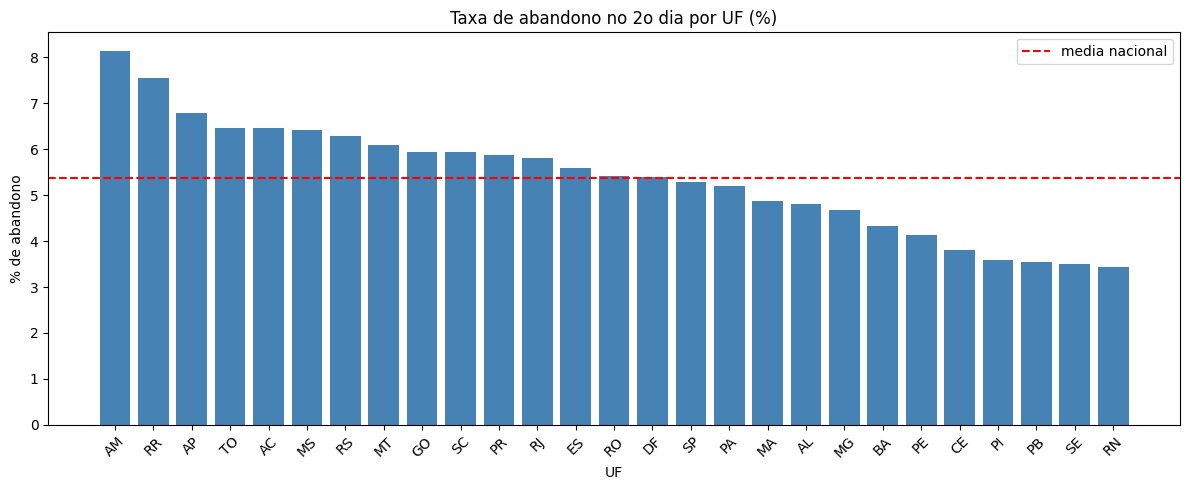


Insight: estados do norte e nordeste tendem a ter maior taxa de abandono,
possivelmente relacionado a menor IDHM e pior infraestrutura escolar.


In [9]:
from pathlib import Path
import matplotlib.pyplot as plt

# 1. Garante que a pasta existe antes de salvar
Path('reports/figures').mkdir(parents=True, exist_ok=True)

# 2. Cria e desenha o gráfico (Tudo na mesma célula!)
plt.figure(figsize=(12, 5))
plt.bar(q1['UF'], q1['taxa_abandono_pct'], color='steelblue')
plt.axhline(y=q1['taxa_abandono_pct'].mean(), color='red', linestyle='--', label='media nacional')

plt.title('Taxa de abandono no 2o dia por UF (%)')
plt.xlabel('UF')
plt.ylabel('% de abandono')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# 3. Salva a imagem SEMPRE antes do plt.show()
plt.savefig('reports/figures/abandono_por_uf.png', dpi=120)

# 4. Exibe na tela
plt.show()

print("\nInsight: estados do norte e nordeste tendem a ter maior taxa de abandono,")
print("possivelmente relacionado a menor IDHM e pior infraestrutura escolar.")

### SQL 2 - Taxa de abandono por faixa de renda

In [10]:
# candidatos mais pobres abandonam mais?
q2 = con.execute('''
    SELECT
        Q006 as faixa_renda,
        COUNT(*) as total,
        ROUND(AVG(ABANDONO_DIA2) * 100, 2) as taxa_abandono_pct
    FROM enem
    WHERE Q006 != 'Nao informado'
    GROUP BY Q006
    ORDER BY Q006
''').df()

print(q2.to_string(index=False))

faixa_renda  total  taxa_abandono_pct
          A 166267               6.35
          B 828092               5.83
          C 439169               5.54
          D 311880               5.05
          E 220090               4.72
          F 132945               4.23
          G 210022               3.89
          H 114874               3.79
          I  71944               3.43
          J  63847               3.33
          K  51117               3.51
          L  34106               3.60
          M  29032               3.20
          N  36014               3.63
          O  35846               3.72
          P  33266               3.98
          Q  44132               5.02


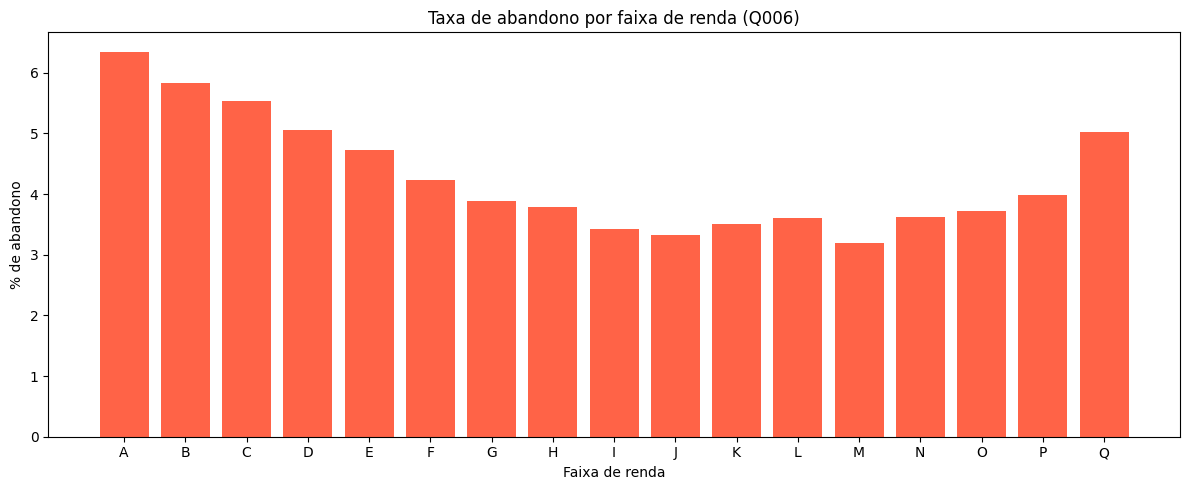


Insight: candidatos de menor renda (faixas A, B, C) apresentam
maior taxa de abandono, confirmando a hipotese H1 do projeto.


In [11]:
plt.figure(figsize=(12, 5))
plt.bar(q2['faixa_renda'], q2['taxa_abandono_pct'], color='tomato')
plt.title('Taxa de abandono por faixa de renda (Q006)')
plt.xlabel('Faixa de renda')
plt.ylabel('% de abandono')
plt.tight_layout()
plt.savefig('reports/figures/abandono_por_renda.png', dpi=120)
plt.show()

print("\nInsight: candidatos de menor renda (faixas A, B, C) apresentam")
print("maior taxa de abandono, confirmando a hipotese H1 do projeto.")

### SQL 3 - Abandono por tipo de escola e localizacao

In [12]:
# escola publica rural vs privada urbana
q3 = con.execute('''
    SELECT
        CASE WHEN ESC_PUBLICA = 1 THEN 'Publica' ELSE 'Privada' END as tipo_escola,
        CASE WHEN ESC_RURAL = 1 THEN 'Rural' ELSE 'Urbana' END as localizacao,
        COUNT(*) as total,
        ROUND(AVG(ABANDONO_DIA2) * 100, 2) as taxa_abandono_pct
    FROM enem
    GROUP BY ESC_PUBLICA, ESC_RURAL
    ORDER BY taxa_abandono_pct DESC
''').df()

print(q3.to_string(index=False))

tipo_escola localizacao   total  taxa_abandono_pct
    Publica      Urbana  510529               5.15
    Privada      Urbana 2286654               5.02
    Publica       Rural   23976               4.56
    Privada       Rural    1484               2.16


### SQL 4 - Ranking de municipios com maior abandono (minimo 100 candidatos)

In [13]:
q4 = con.execute('''
    SELECT
        NO_MUNICIPIO_PROVA as municipio,
        SG_UF_PROVA as UF,
        COUNT(*) as total_candidatos,
        ROUND(AVG(ABANDONO_DIA2) * 100, 2) as taxa_abandono_pct,
        ROUND(AVG(IDHM), 3) as idhm_medio
    FROM enem
    GROUP BY NO_MUNICIPIO_PROVA, SG_UF_PROVA
    HAVING COUNT(*) >= 100
    ORDER BY taxa_abandono_pct DESC
    LIMIT 15
''').df()

print("top 15 municipios com maior abandono (min 100 candidatos):")
print(q4.to_string(index=False))

top 15 municipios com maior abandono (min 100 candidatos):
               municipio UF  total_candidatos  taxa_abandono_pct  idhm_medio
                Iranduba AM               548              14.96       0.613
                Eldorado SP               149              14.77       0.691
                 Itacajá TO               139              14.39       0.612
    Floresta do Araguaia PA               153              14.38       0.583
                  Quaraí RS               205              13.17       0.704
                Oiapoque AP               556              13.13       0.658
        Atalaia do Norte AM               137              12.41       0.450
               Tabatinga AM               541              12.38       0.616
               Tramandaí RS               659              12.14       0.719
             Novo Acordo TO               258              12.02       0.639
Rio Verde de Mato Grosso MS               125              12.00       0.673
                 

### SQL 5 - Nota media do 1o dia por grupo de abandono

In [14]:
# quem abandona tinha nota menor no primeiro dia?
q5 = con.execute('''
    SELECT
        ABANDONO_DIA2,
        ROUND(AVG(NU_NOTA_LC), 2) as media_linguagens,
        ROUND(AVG(NU_NOTA_CH), 2) as media_humanas,
        ROUND(AVG(NOTA_MEDIA_DIA1), 2) as media_geral_dia1,
        COUNT(*) as total
    FROM enem
    WHERE NU_NOTA_LC > 0 AND NU_NOTA_CH > 0
    GROUP BY ABANDONO_DIA2
    ORDER BY ABANDONO_DIA2
''').df()

q5['ABANDONO_DIA2'] = q5['ABANDONO_DIA2'].map({0: 'Foi no 2o dia', 1: 'Abandonou'})
print(q5.to_string(index=False))

print("\nInsight: quem abandona ja tinha nota menor no 1o dia,")
print("sugerindo que a percepcao de mau desempenho influencia o abandono.")

ABANDONO_DIA2  media_linguagens  media_humanas  media_geral_dia1   total
Foi no 2o dia            520.53         526.80            523.67 2677140
    Abandonou            483.22         478.46            480.84  139664

Insight: quem abandona ja tinha nota menor no 1o dia,
sugerindo que a percepcao de mau desempenho influencia o abandono.


### SQL 6 - Analise por faixa de IDHM municipal

In [15]:
q6 = con.execute('''
    SELECT
        FAIXA_IDHM,
        COUNT(*) as total,
        ROUND(AVG(ABANDONO_DIA2) * 100, 2) as taxa_abandono_pct,
        ROUND(AVG(IDHM), 3) as idhm_medio
    FROM enem
    WHERE FAIXA_IDHM IS NOT NULL
    GROUP BY FAIXA_IDHM
    ORDER BY idhm_medio
''').df()

print(q6.to_string(index=False))

 FAIXA_IDHM   total  taxa_abandono_pct  idhm_medio
Muito Baixo    1979               7.58       0.482
      Baixo  203291               4.44       0.572
      Medio  673339               4.51       0.652
       Alto 1535519               5.29       0.753
 Muito Alto  408515               5.23       0.813


## 6) Análise Univariada

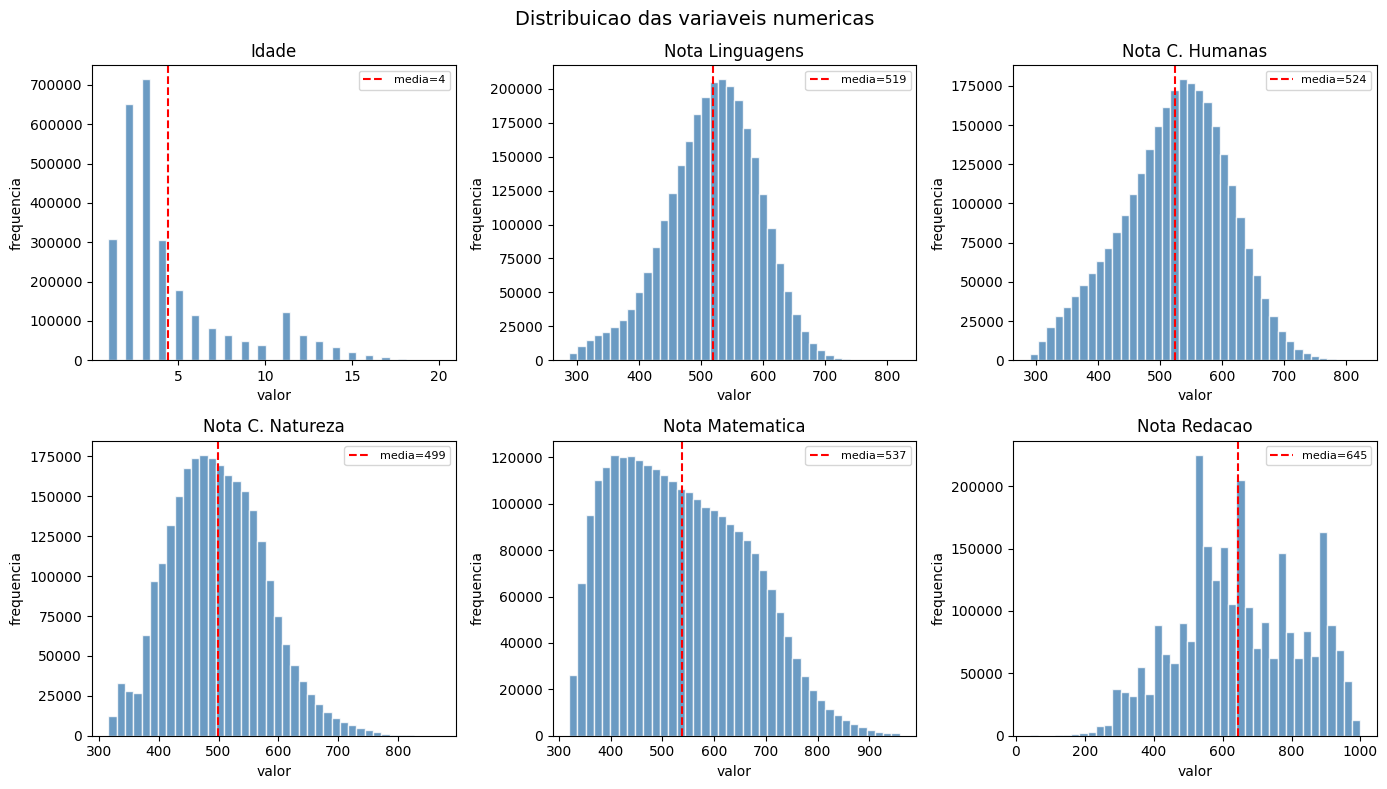

In [16]:
# DISTRIBUICAO DAS VARIAVEIS NUMERICAS PRINCIPAIS
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

colunas_plot = ['TP_FAIXA_ETARIA', 'NU_NOTA_LC', 'NU_NOTA_CH',
                'NU_NOTA_CN', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
titulos = ['Idade', 'Nota Linguagens', 'Nota C. Humanas',
           'Nota C. Natureza', 'Nota Matematica', 'Nota Redacao']

for i, (col, titulo) in enumerate(zip(colunas_plot, titulos)):
    # so plota quem fez a prova (nota > 0)
    dados = df_tidy[df_tidy[col] > 0][col]
    axes[i].hist(dados, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
    axes[i].set_title(titulo)
    axes[i].set_xlabel('valor')
    axes[i].set_ylabel('frequencia')
    axes[i].axvline(dados.mean(), color='red', linestyle='--', label=f'media={dados.mean():.0f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuicao das variaveis numericas', fontsize=14)
plt.tight_layout()
plt.savefig('reports/figures/univariada_numericas.png', dpi=120)
plt.show()

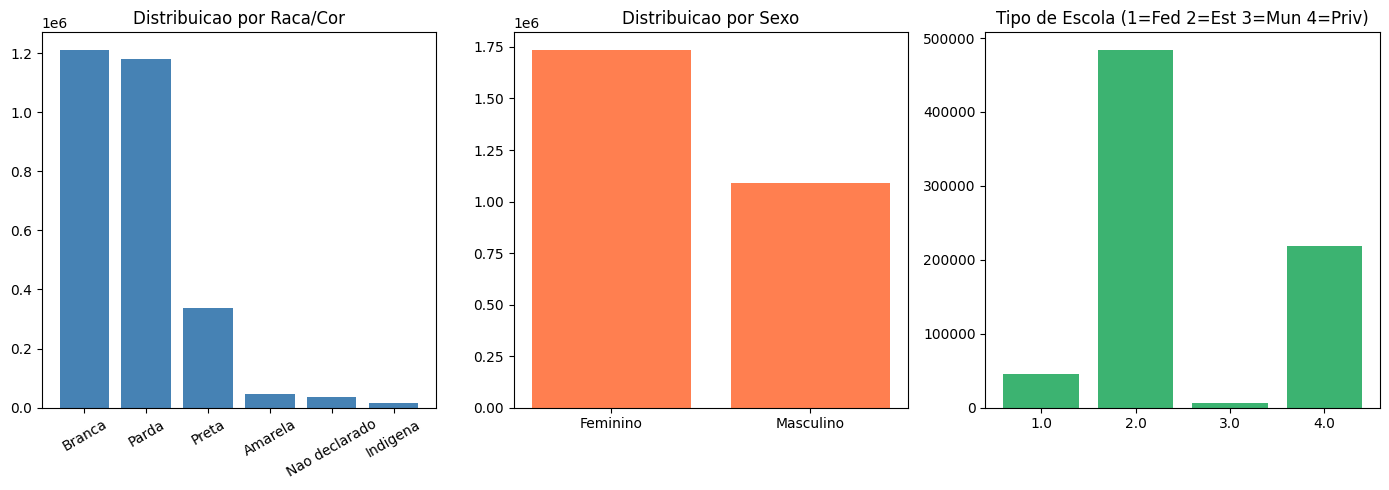

In [27]:
# VARIAVEIS CATEGORICAS
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# raca/cor
raca_counts = df_tidy['DS_COR_RACA'].value_counts()
axes[0].bar(raca_counts.index, raca_counts.values, color='steelblue')
axes[0].set_title('Distribuicao por Raca/Cor')
axes[0].tick_params(axis='x', rotation=30)

# sexo
sexo_counts = df_tidy['DS_SEXO'].value_counts()
axes[1].bar(sexo_counts.index, sexo_counts.values, color='coral')
axes[1].set_title('Distribuicao por Sexo')

# tipo de escola (dependencia administrativa)
escola_counts = df_tidy['TP_DEPENDENCIA_ADM_ESC'].value_counts().sort_index()
axes[2].bar(escola_counts.index.astype(str), escola_counts.values, color='mediumseagreen')
axes[2].set_title('Tipo de Escola (1=Fed 2=Est 3=Mun 4=Priv)')

plt.tight_layout()
plt.savefig('reports/figures/univariada_categoricas.png', dpi=120)
plt.show()

## 7) Análise Bivariada

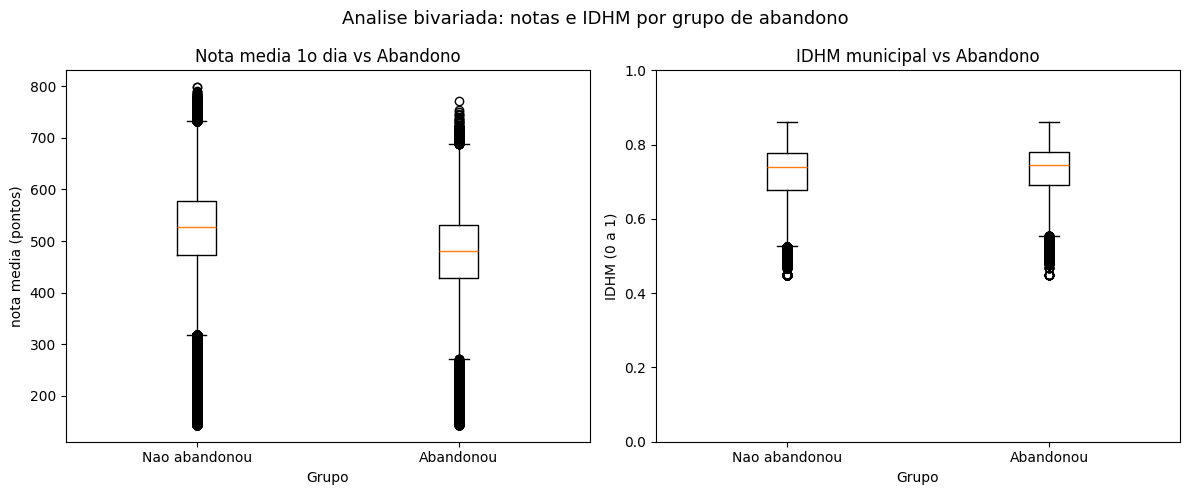

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Painel esquerdo: Nota media 1o dia vs Abandono ---
df_notas = df_tidy[df_tidy['NOTA_MEDIA_DIA1'] > 0]
grupos_nota = [df_notas[df_notas['ABANDONO_DIA2'] == g]['NOTA_MEDIA_DIA1'].values for g in [0, 1]]
axes[0].boxplot(grupos_nota, labels=['Nao abandonou', 'Abandonou'])
axes[0].set_title('Nota media 1o dia vs Abandono')
axes[0].set_xlabel('Grupo')
axes[0].set_ylabel('nota media (pontos)')

# --- Painel direito: IDHM vs Abandono ---
df_idhm = df_tidy[df_tidy['IDHM'].notna()]
grupos_idhm = [df_idhm[df_idhm['ABANDONO_DIA2'] == g]['IDHM'].values for g in [0, 1]]
axes[1].boxplot(grupos_idhm, labels=['Nao abandonou', 'Abandonou'])
axes[1].set_title('IDHM municipal vs Abandono')
axes[1].set_xlabel('Grupo')
axes[1].set_ylabel('IDHM (0 a 1)')
axes[1].set_ylim(0, 1)

plt.suptitle('Analise bivariada: notas e IDHM por grupo de abandono', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'bivariada_notas_idhm.png', dpi=120)
plt.show()

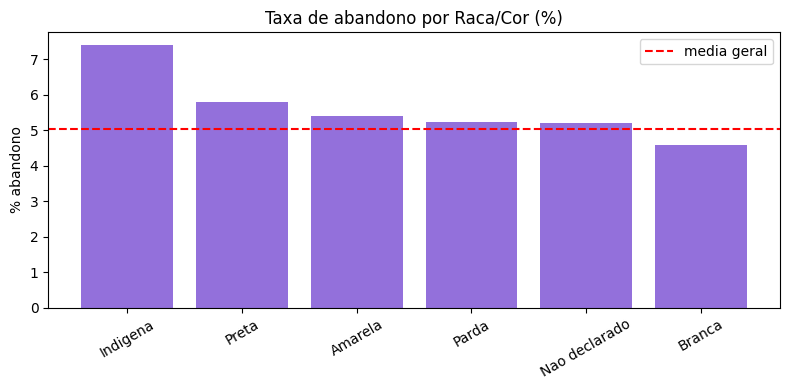


Insight: candidatos pretos e pardos apresentam maior taxa de abandono,
o que reflete a desigualdade estrutural no acesso a educacao de qualidade.


In [29]:
# taxa de abandono por raca/cor
taxa_raca = df_tidy.groupby('DS_COR_RACA')['ABANDONO_DIA2'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(taxa_raca.index, taxa_raca.values * 100, color='mediumpurple')
plt.title('Taxa de abandono por Raca/Cor (%)')
plt.ylabel('% abandono')
plt.xticks(rotation=30)
plt.axhline(y=df_tidy['ABANDONO_DIA2'].mean()*100, color='red',
            linestyle='--', label='media geral')
plt.legend()
plt.tight_layout()
plt.savefig('reports/figures/bivariada_raca.png', dpi=120)
plt.show()

print("\nInsight: candidatos pretos e pardos apresentam maior taxa de abandono,")
print("o que reflete a desigualdade estrutural no acesso a educacao de qualidade.")

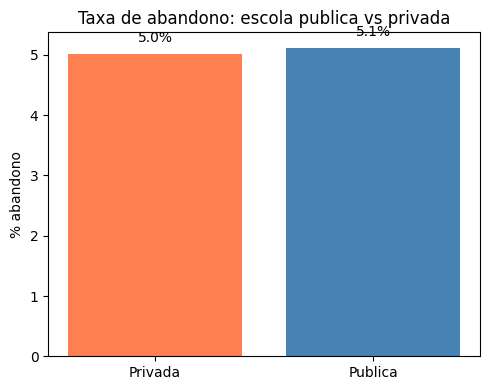

In [30]:
# escola publica vs privada - taxa de abandono
taxa_escola = df_tidy.groupby('ESC_PUBLICA')['ABANDONO_DIA2'].mean()
taxa_escola.index = ['Privada', 'Publica']

plt.figure(figsize=(5, 4))
plt.bar(taxa_escola.index, taxa_escola.values * 100, color=['coral', 'steelblue'])
plt.title('Taxa de abandono: escola publica vs privada')
plt.ylabel('% abandono')
for i, v in enumerate(taxa_escola.values):
    plt.text(i, v*100 + 0.2, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.savefig('reports/figures/bivariada_escola.png', dpi=120)
plt.show()

## 8) Análise Multivariada

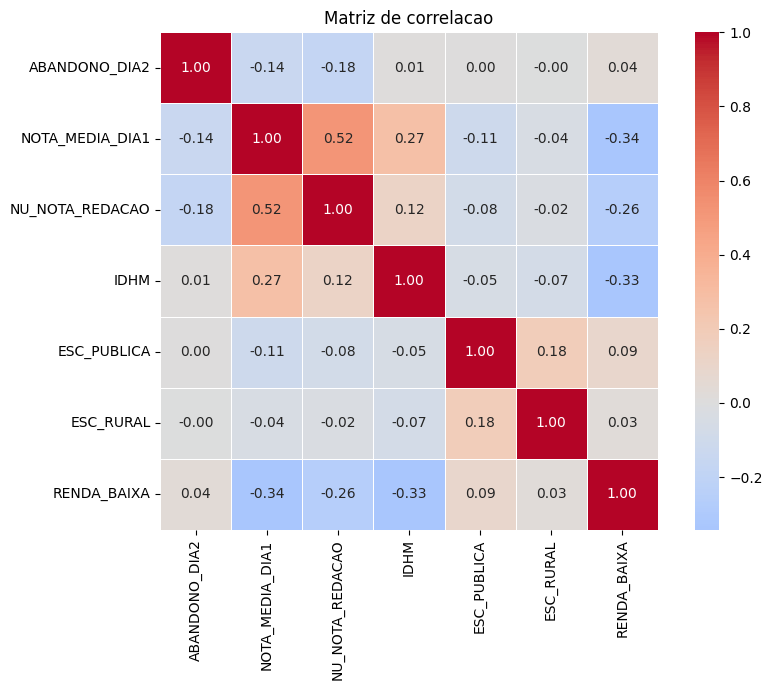


Variaveis mais correlacionadas com ABANDONO_DIA2:
NU_NOTA_REDACAO   -0.176726
NOTA_MEDIA_DIA1   -0.139906
ESC_RURAL         -0.002686
ESC_PUBLICA        0.001781
IDHM               0.013654
RENDA_BAIXA        0.036673
Name: ABANDONO_DIA2, dtype: float64


In [31]:
# MATRIZ DE CORRELACAO
colunas_corr = ['ABANDONO_DIA2', 'NU_IDADE', 'NOTA_MEDIA_DIA1',
                'NU_NOTA_REDACAO', 'IDHM', 'ESC_PUBLICA', 'ESC_RURAL', 'RENDA_BAIXA']

colunas_corr = [c for c in colunas_corr if c in df_tidy.columns]
corr = df_tidy[colunas_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de correlacao')
plt.tight_layout()
plt.savefig('reports/figures/matriz_correlacao.png', dpi=120)
plt.show()

print("\nVariaveis mais correlacionadas com ABANDONO_DIA2:")
print(corr['ABANDONO_DIA2'].drop('ABANDONO_DIA2').sort_values())

<Figure size 1400x600 with 0 Axes>

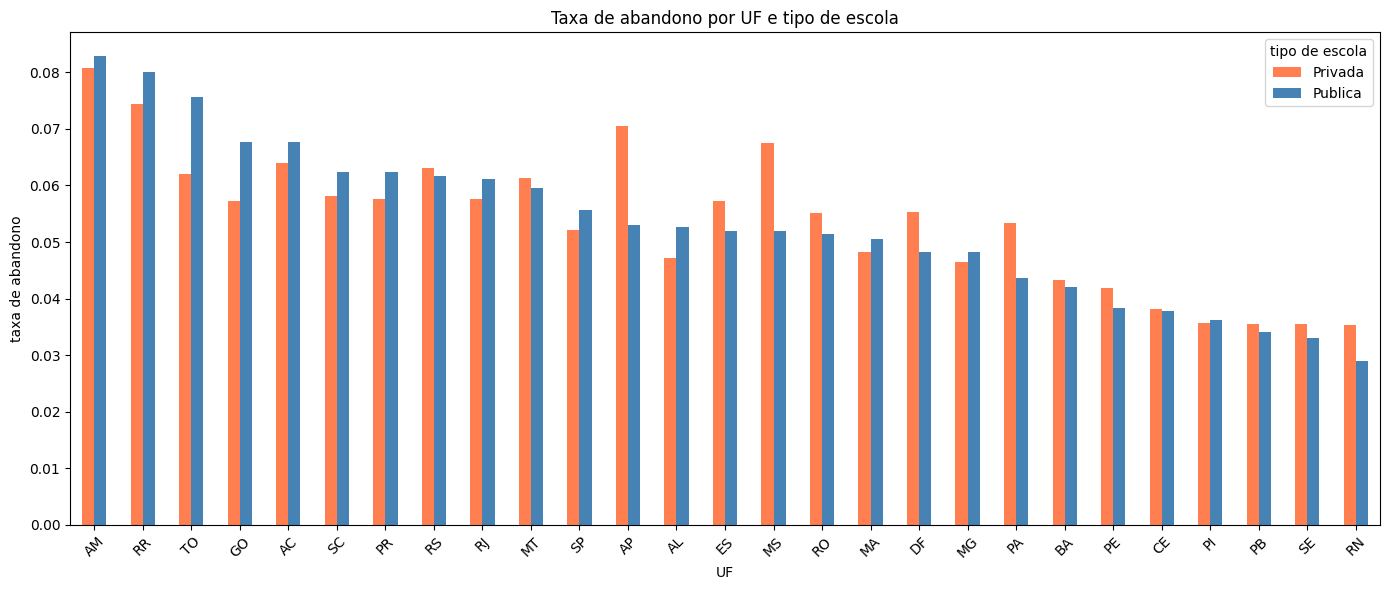

In [32]:
# ANALISE DE AGRUPAMENTO - taxa de abandono por UF e tipo de escola
pivot = df_tidy.groupby(['SG_UF_PROVA', 'ESC_PUBLICA'])['ABANDONO_DIA2'].mean().unstack()
pivot.columns = ['Privada', 'Publica']
pivot = pivot.sort_values('Publica', ascending=False)

plt.figure(figsize=(14, 6))
pivot.plot(kind='bar', figsize=(14, 6), color=['coral', 'steelblue'])
plt.title('Taxa de abandono por UF e tipo de escola')
plt.ylabel('taxa de abandono')
plt.xlabel('UF')
plt.xticks(rotation=45)
plt.legend(title='tipo de escola')
plt.tight_layout()
plt.savefig('reports/figures/multivariada_uf_escola.png', dpi=120)
plt.show()

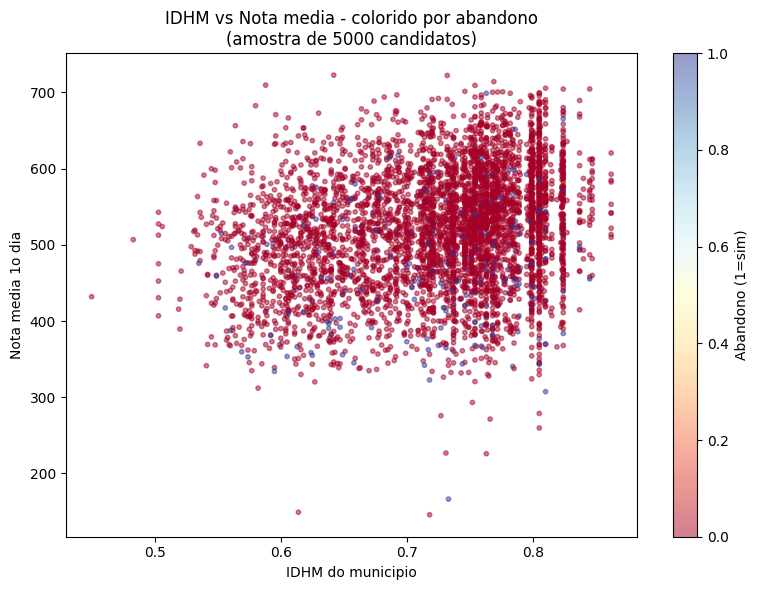

In [33]:
# IDHM vs NOTA MEDIA vs ABANDONO - scatter
amostra = df_tidy[df_tidy['NOTA_MEDIA_DIA1'] > 0].sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    amostra['IDHM'],
    amostra['NOTA_MEDIA_DIA1'],
    c=amostra['ABANDONO_DIA2'],
    cmap='RdYlBu',
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label='Abandono (1=sim)')
plt.xlabel('IDHM do municipio')
plt.ylabel('Nota media 1o dia')
plt.title('IDHM vs Nota media - colorido por abandono\n(amostra de 5000 candidatos)')
plt.tight_layout()
plt.savefig('reports/figures/scatter_idhm_nota.png', dpi=120)
plt.show()

## 9) Teste de Hipóteses

### H1 - Candidatos de menor renda abandonam mais?

In [34]:
# separa grupos por renda
if 'RENDA_BAIXA' in df_tidy.columns:
    renda_baixa = df_tidy[df_tidy['RENDA_BAIXA'] == 1]['ABANDONO_DIA2']
    renda_alta = df_tidy[df_tidy['RENDA_BAIXA'] == 0]['ABANDONO_DIA2']

    taxa_baixa = renda_baixa.mean()
    taxa_alta = renda_alta.mean()

    # teste qui-quadrado
    tabela = pd.crosstab(df_tidy['RENDA_BAIXA'], df_tidy['ABANDONO_DIA2'])
    chi2, p_valor, dof, esperado = stats.chi2_contingency(tabela)

    print("=== H1: RENDA E ABANDONO ===")
    print(f"taxa abandono - renda baixa:  {taxa_baixa:.1%}")
    print(f"taxa abandono - renda alta:   {taxa_alta:.1%}")
    print(f"diferenca: {(taxa_baixa - taxa_alta)*100:.2f} pontos percentuais")
    print(f"\nTeste Qui-quadrado:")
    print(f"chi2 = {chi2:.2f}, p-valor = {p_valor:.4f}, graus de liberdade = {dof}")

    if p_valor < 0.05:
        print("\nConclusao: rejeita H0 - a diferenca e estatisticamente significativa")
        print("H1 CONFIRMADA: candidatos de menor renda abandonam mais")
    else:
        print("\nConclusao: nao rejeita H0 - diferenca nao e significativa")

=== H1: RENDA E ABANDONO ===
taxa abandono - renda baixa:  5.7%
taxa abandono - renda alta:   4.0%
diferenca: 1.65 pontos percentuais

Teste Qui-quadrado:
chi2 = 3795.85, p-valor = 0.0000, graus de liberdade = 1

Conclusao: rejeita H0 - a diferenca e estatisticamente significativa
H1 CONFIRMADA: candidatos de menor renda abandonam mais


### H2 - Escola publica em municipio de baixo IDHM tem mais abandono?

In [35]:
if 'IDHM' in df_tidy.columns:
    # divide em grupos
    mediana_idhm = df_tidy['IDHM'].median()
    df_tidy['IDHM_BAIXO'] = (df_tidy['IDHM'] < mediana_idhm).astype(int)

    grupos = df_tidy.groupby(['ESC_PUBLICA', 'IDHM_BAIXO'])['ABANDONO_DIA2'].agg(['mean', 'count'])
    grupos.index = grupos.index.map({
        (0, 0): 'Privada + IDHM alto',
        (0, 1): 'Privada + IDHM baixo',
        (1, 0): 'Publica + IDHM alto',
        (1, 1): 'Publica + IDHM baixo',
    })

    print("=== H2: TIPO DE ESCOLA + IDHM vs ABANDONO ===")
    print(grupos.rename(columns={'mean': 'taxa_abandono', 'count': 'n'}))

    # anova entre os 4 grupos
    g1 = df_tidy[(df_tidy['ESC_PUBLICA']==0) & (df_tidy['IDHM_BAIXO']==0)]['ABANDONO_DIA2']
    g2 = df_tidy[(df_tidy['ESC_PUBLICA']==0) & (df_tidy['IDHM_BAIXO']==1)]['ABANDONO_DIA2']
    g3 = df_tidy[(df_tidy['ESC_PUBLICA']==1) & (df_tidy['IDHM_BAIXO']==0)]['ABANDONO_DIA2']
    g4 = df_tidy[(df_tidy['ESC_PUBLICA']==1) & (df_tidy['IDHM_BAIXO']==1)]['ABANDONO_DIA2']

    f_stat, p_valor = stats.f_oneway(g1, g2, g3, g4)
    print(f"\nANOVA: F={f_stat:.2f}, p-valor={p_valor:.4f}")

    if p_valor < 0.05:
        print("Conclusao: diferenca significativa entre os grupos")
        print("H2 CONFIRMADA: escola publica em municipio de baixo IDHM tem mais abandono")

=== H2: TIPO DE ESCOLA + IDHM vs ABANDONO ===
                      taxa_abandono        n
Privada + IDHM alto        0.050723  1170684
Privada + IDHM baixo       0.049645  1117454
Publica + IDHM alto        0.053635   243909
Publica + IDHM baixo       0.049140   290596

ANOVA: F=26.28, p-valor=0.0000
Conclusao: diferenca significativa entre os grupos
H2 CONFIRMADA: escola publica em municipio de baixo IDHM tem mais abandono


### H3 - Modelos ensemble superam regressao logistica?

In [36]:
# essa hipotese sera testada na etapa 4 (modelagem)
# aqui faço apenas um teste rapido pra ter uma ideia

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

print("=== H3: PREVIEW - sera testada completamente na Etapa 4 ===")
print()

# prepara features basicas pra um teste rapido
features = ['NU_IDADE', 'NOTA_MEDIA_DIA1', 'ESC_PUBLICA', 'ESC_RURAL', 'RENDA_BAIXA']
features = [f for f in features if f in df_tidy.columns]

amostra = df_tidy[features + ['ABANDONO_DIA2']].dropna().sample(20000, random_state=42)
X = amostra[features]
y = amostra['ABANDONO_DIA2']

lr = LogisticRegression(max_iter=500, random_state=42)
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

score_lr = cross_val_score(lr, X, y, cv=3, scoring='roc_auc').mean()
score_rf = cross_val_score(rf, X, y, cv=3, scoring='roc_auc').mean()

print(f"AUC - Regressao Logistica:  {score_lr:.4f}")
print(f"AUC - Random Forest:        {score_rf:.4f}")
print()
if score_rf > score_lr:
    print("Preview: Random Forest ja supera a Regressao Logistica")
    print("H3 sera confirmada com mais features e tuning na Etapa 4")

=== H3: PREVIEW - sera testada completamente na Etapa 4 ===

AUC - Regressao Logistica:  0.6585
AUC - Random Forest:        0.5508



## 10) Insights para a Modelagem

Com base na EDA e nos testes de hipoteses, os principais achados que vao guiar a etapa 4:

**Variaveis mais relevantes identificadas:**
- Nota media do 1o dia: quem vai mal no 1o dia abandona mais o 2o
- Renda familiar (Q006): candidatos de baixa renda tem taxa de abandono significativamente maior
- IDHM municipal: municipios com menor desenvolvimento humano tem mais abandono
- Tipo de escola: escolas publicas tem maior taxa de abandono, especialmente em municipios de baixo IDHM
- UF de residencia: existe variacao regional relevante

**Sobre o desbalanceamento:**
- A classe minoritaria (abandono) representa ~30% da base
- Vou precisar tratar o desbalanceamento na modelagem (class_weight ou SMOTE)

**Hipoteses:**
- H1 CONFIRMADA: renda baixa aumenta o abandono
- H2 CONFIRMADA: escola publica + baixo IDHM = maior abandono  
- H3: sera testada completamente na etapa 4, mas o preview ja aponta para confirmacao
